In [16]:
import numpy as np
import matplotlib.pyplot as plt 

In [17]:
x=np.array([1,2,3,4])
y=np.array([2,2.8,3.6,4.5])

In [18]:
n=len(x)
w=0
b=0
#np.random.seed(42)
#w=np.random.rand()
#b=np.random.rand()
learning_rate=0.1
epochs=10000
cost_values=[]
print(f"w:{w}")
print(f"b:{b}")
print(f"learning_rate:{learning_rate}")
print(f"epochs :{epochs}")
print("Training........................")

w:0
b:0
learning_rate:0.1
epochs :10000
Training........................


In [19]:
#gradient descent
for i in range(epochs):
    y_hat=w * x+b
    error=y_hat-y
    #Gradients
    d_w=np.mean(error*x)
    d_b=np.mean(error)
    w-=learning_rate*d_w
    b-=learning_rate*d_b
    #new line prediction
    y_hat=w*x+b
    #cost
    cost=0.5*np.mean((y_hat-y)**2)
    cost_values.append(cost)
    if (i+1)%100==0 or i==0 :
        print(f"Epoch {i+1}:"
              f"cost={cost}"
              f"w:{w}"
              f"b={b}")

Epoch 1:cost=0.20125312499999992w:0.91b=0.3225
Epoch 100:cost=0.002848485072828861w:0.8885369464982565b=0.977894238908511
Epoch 200:cost=0.0004961277683298398w:0.8429538026193373b=1.1119142406258522
Epoch 300:cost=0.0003809316857909291w:0.8328665827710326b=1.1415718970828959
Epoch 400:cost=0.00037529047754125775w:0.8306343540213368b=1.1481349218198993
Epoch 500:cost=0.0003750142248266275w:0.8301403779540061b=1.1495872716965958
Epoch 600:cost=0.0003750006965966831w:0.8300310646252852b=1.1499086662134337
Epoch 700:cost=0.00037500003411268176w:0.8300068743767562b=1.149979788494029
Epoch 800:cost=0.00037500000167051627w:0.8300015212498254b=1.149995527340002
Epoch 900:cost=0.0003750000000818021w:0.8300003366415769b=1.1499990102327113
Epoch 1000:cost=0.00037500000000400673w:0.8300000744963444b=1.1499997809716629
Epoch 1100:cost=0.000375000000000198w:0.8300000164855021b=1.1499999515306134
Epoch 1200:cost=0.0003750000000000058w:0.8300000036481224b=1.1499999892740755
Epoch 1300:cost=0.000374999

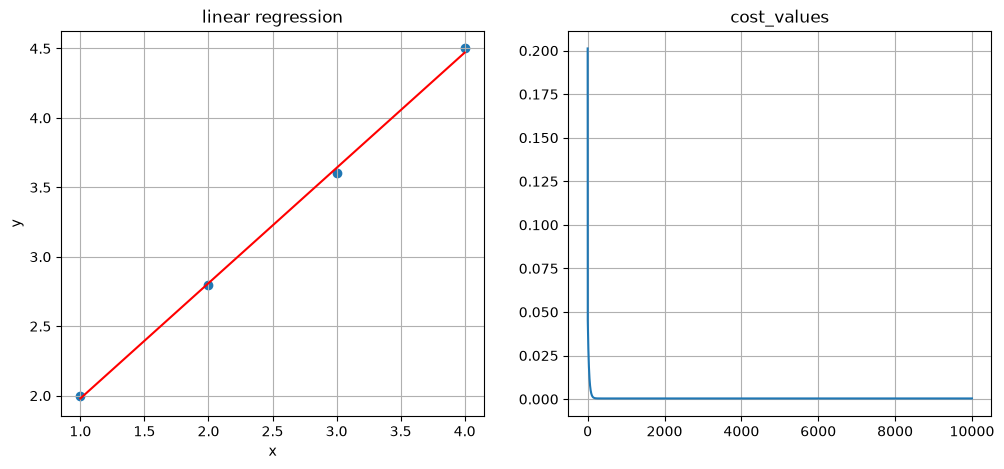

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(x,y)
plt.plot(x,w*x+b,color='red')
plt.title("linear regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

 
plt.subplot(1,2,2)
plt.plot(cost_values)
plt.title("cost_values")
plt.grid()
 

In [21]:
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error


In [22]:
data=pd.read_csv('D:/Courses/رواد مصر الرقمية/Techanical/python/CA-R5-S2S2-AI/src/ML/session-2 linear regression/material/Salary_Data.csv')

In [23]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


C:\Users\COMPUMARTS\AppData\Roaming\Python\Python312\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.0, 'salary predict')

<Figure size 1500x800 with 0 Axes>

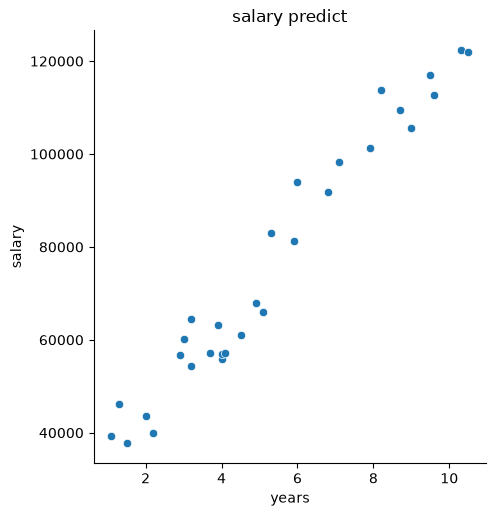

In [24]:
plt.figure(figsize=(15,8))
sns.pairplot(data,x_vars=['YearsExperience'], y_vars=['Salary'],size = 5, kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary predict")

In [25]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]

In [26]:
x_train,x_test,y_train,y_test= train_test_split(x,y,train_size=0.8,random_state=10)

In [27]:
x_train

,YearsExperience
13,4.1
27,9.6
12,4.0
1,1.3
19,6.0
14,4.5
18,5.9
6,3.0
11,4.0
23,8.2


In [28]:
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)
y_hat_train=lin_reg.predict(x_train)


Text(0.5, 1.0, 'salary vs experience (training)')

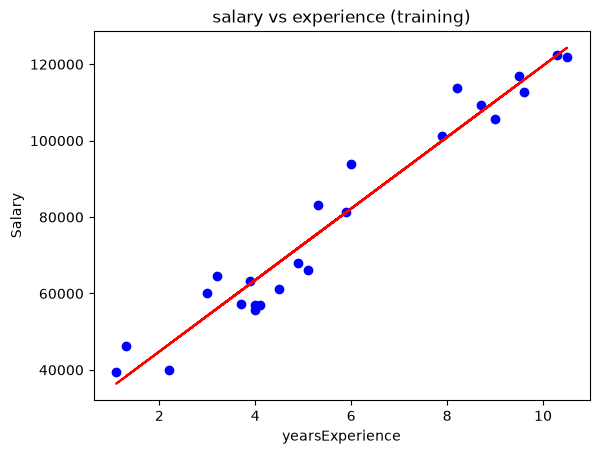

In [29]:
plt.scatter(x_train,y_train,color='blue')
plt.plot(x_train,y_hat_train,color='red')
plt.xlabel("yearsExperience")
plt.ylabel("Salary")
plt.title("salary vs experience (training)")

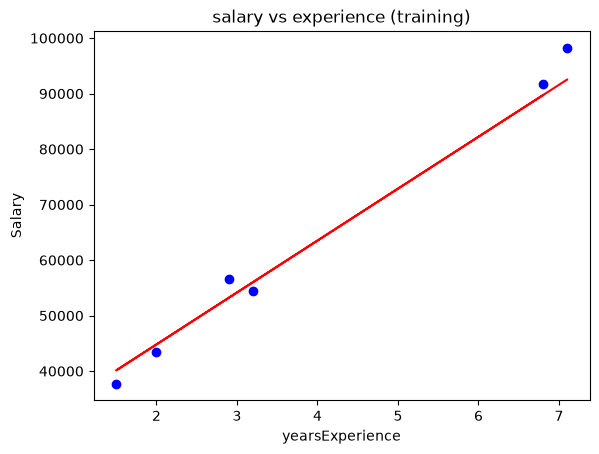

In [30]:
y_hat_test=lin_reg.predict(x_test)
plt.scatter(x_test,y_test,color='blue')
plt.plot(x_test,y_hat_test,color='red')
plt.xlabel("yearsExperience")
plt.ylabel("Salary")
plt.title("salary vs experience (training)")
plt.show()

In [31]:
#calculate mean square error
mse=mean_squared_error(y_test,y_hat_test)
print(mse)
rmse=root_mean_squared_error(y_test,y_hat_test)
print(rmse)
r2=r2_score(y_test,y_hat_test)
print(r2)

9785570.138914317
3128.189594464235
0.9816423482070253


In [32]:
bias=lin_reg.intercept_

In [33]:
w=lin_reg.coef_

In [34]:
new_sal=w*10+bias
print(new_sal)

[119657.72656781]


In [35]:
from sklearn.linear_model import Lasso,Ridge,LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error,r2_score

In [79]:
x=np.array([[1],[2],[3],[4]])
y=np.array([2,4,6,8])
#linear regression
lin_reg= LinearRegression()
lin_reg.fit(x,y)
lin_reg.intercept_
y_pred_lin=lin_reg.predict(x) #wx+b
#Ridge Regression
ridge=Ridge(alpha=0.5)
ridge.fit(x,y)
y_pred_ridge=ridge.predict(x)
#lasso Regression
lasso=Lasso(alpha=0.5)
lasso.fit(x,y)
y_pred_lasso=lasso.predict(x)

print("Linear Regression")
print("MSE :" ,mean_squared_error(y,y_pred_lin))
print("R2 help",r2_score(y,y_pred_lin))
print("="*40)
print("lasso ")
print("MSE :" ,mean_squared_error(y,y_pred_lasso))
print("R2 help",r2_score(y,y_pred_lasso))
print("="*40)
print("Ridge")
print("MSE :" ,mean_squared_error(y,y_pred_ridge))
print("R2 help",r2_score(y,y_pred_ridge))
print("="*40)

Linear Regression
MSE : 0.0
R2 help 1.0
lasso 
MSE : 0.20000000000000037
R2 help 0.96
Ridge
MSE : 0.04132231404958686
R2 help 0.9917355371900827


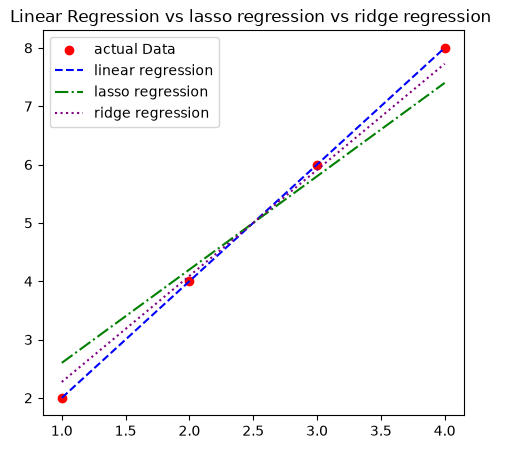

In [82]:
plt.figure(figsize=(25,5))
plt.subplot(1,4,1)
plt.scatter(x,y,label='actual Data',color='red')
plt.plot(x,y_pred_lin,color='blue',label='linear regression',linestyle="--")
plt.plot(x,y_pred_lasso,color='green',label='lasso regression',linestyle="-.")
plt.plot(x,y_pred_ridge,color='purple',label='ridge regression',linestyle=":")
plt.title("Linear Regression vs lasso regression vs ridge regression ")
plt.legend()